# 2026 KSMPC 여름학교
## 자동음악채보(Automatic Music Transcription) 실습

이 실습에서는 오디오 신호를 분석하여 음의 시작 시점, 길이, 높이 등을 추정하고 MIDI로 변환하는 **자동음악채보(AMT)** 기술을 살펴봅니다.

대표적인 채보 모델 두 가지를 직접 실행합니다.

- **Transkun**: 피아노 연주에 특화된 자동 채보 모델
- **Basic Pitch**: 피아노뿐 아니라 현악기, 보컬 등 다양한 악기를 처리할 수 있는 다중음 채보 모델

각 모델의 결과를 피아노롤과 음높이 궤적으로 시각화하고, 생성된 MIDI를 다시 소리로 들어봅니다.

### 실행 방법

1. Colab 메뉴에서 `런타임 → 런타임 유형 변경 → T4 GPU`를 선택합니다. GPU가 없어도 실행은 가능하지만 Transkun이 느릴 수 있습니다.
2. 아래 셀을 위에서부터 차례로 실행합니다. 한꺼번에 실행하려면 `런타임 → 모두 실행`을 선택합니다.
3. 자료를 찾지 못하면 파일 선택 창이 나타납니다. 배포받은 실습 ZIP 파일을 선택하세요.

> Colab 런타임은 종료되면 생성 파일이 사라집니다. 보관하려는 MIDI는 실습이 끝나기 전에 내려받으세요.

출처: GCT731-2026 github practice

## 0. 실습 환경 준비

먼저 모델과 MIDI 합성에 필요한 패키지를 설치합니다. Colab 런타임을 새로 연결할 때마다 한 번 실행해야 하며 약 2~3분 정도 걸릴 수 있습니다.

In [ ]:
# 필요한 Linux 프로그램과 Python 패키지 설치
import subprocess
import sys

subprocess.run(
    ["apt-get", "update", "-qq"],
    check=True,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.STDOUT,
)
subprocess.run(
    ["apt-get", "install", "-y", "-qq", "fluidsynth", "fluid-soundfont-gm"],
    check=True,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.STDOUT,
)
subprocess.run(
    [
        sys.executable, "-m", "pip", "install", "-q",
        "transkun==2.0.1", "pretty_midi", "pyfluidsynth",
        "mir_eval", "resampy<0.4.3", "onnxruntime",
    ],
    check=True,
)

# 최신 Colab과의 TensorFlow 버전 충돌을 피하고 ONNX 모델을 사용합니다.
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "--no-deps", "basic-pitch==0.4.0"],
    check=True,
)

print("✅ 패키지 설치가 끝났습니다.")

✅ 패키지 설치가 끝났습니다.


## 1. 실습 자료 불러오기

노트북은 다음 네 파일을 자동으로 찾습니다.

- `chopin_op28_no4.wav`
- `Chopin_Prelude_Op_24_No.4.png`
- `Beethoven_strqrt.wav`
- `Beethovon_String_Quartet_No.1_Op_18.png`

왼쪽의 **파일** 창에 실습 폴더를 드래그해 두었다면 바로 다음 셀을 실행하세요. 폴더 업로드가 잘 되지 않으면 배포된 `KSMPC_AMT_실습자료.zip`을 선택해도 됩니다.

In [ ]:
# /content 아래에서 실습 파일을 찾고, 없으면 업로드 창을 엽니다.
from pathlib import Path
import zipfile

CONTENT = Path("/content")
REQUIRED_FILES = {
    "chopin_audio": "chopin_op28_no4.wav",
    "chopin_score": "Chopin_Prelude_Op_24_No.4.png",
    "beethoven_audio": "Beethoven_strqrt.wav",
    "beethoven_score": "Beethovon_String_Quartet_No.1_Op_18.png",
}


def find_materials():
    found = {}
    for key, filename in REQUIRED_FILES.items():
        matches = list(CONTENT.rglob(filename))
        if matches:
            found[key] = matches[0]
    return found


materials = find_materials()

if len(materials) != len(REQUIRED_FILES):
    print("실습 자료가 아직 없습니다. 실습 ZIP 또는 네 개의 자료 파일을 선택하세요.")
    from google.colab import files
    uploaded = files.upload()

    # ZIP을 선택했다면 자동으로 압축을 풉니다.
    for filename in uploaded:
        uploaded_path = CONTENT / filename
        if zipfile.is_zipfile(uploaded_path):
            extract_dir = CONTENT / "ksmpc_amt_materials"
            extract_dir.mkdir(exist_ok=True)
            with zipfile.ZipFile(uploaded_path) as archive:
                archive.extractall(extract_dir)

    materials = find_materials()

missing = [name for key, name in REQUIRED_FILES.items() if key not in materials]
if missing:
    raise FileNotFoundError("찾지 못한 파일: " + ", ".join(missing))

CHOPIN_AUDIO = materials["chopin_audio"]
CHOPIN_SCORE = materials["chopin_score"]
BEETHOVEN_AUDIO = materials["beethoven_audio"]
BEETHOVEN_SCORE = materials["beethoven_score"]
OUTPUT_DIR = CONTENT / "ksmpc_amt_results"
OUTPUT_DIR.mkdir(exist_ok=True)

print("✅ 실습 자료를 모두 찾았습니다.")
for key, path in materials.items():
    print(f"  {key}: {path}")

실습 자료가 아직 없습니다. 실습 ZIP 또는 네 개의 자료 파일을 선택하세요.


Saving KSMPC_AMT_실습자료.zip to KSMPC_AMT_실습자료.zip
✅ 실습 자료를 모두 찾았습니다.
  chopin_audio: /content/ksmpc_amt_materials/chopin_op28_no4.wav
  chopin_score: /content/ksmpc_amt_materials/Chopin_Prelude_Op_24_No.4.png
  beethoven_audio: /content/ksmpc_amt_materials/Beethoven_strqrt.wav
  beethoven_score: /content/ksmpc_amt_materials/Beethovon_String_Quartet_No.1_Op_18.png


In [ ]:
# 공통 라이브러리 불러오기
import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
import IPython.display as ipd

print("✅ 실습 준비 완료")

✅ 실습 준비 완료


# 2. Transkun: 피아노 자동 채보

Transkun은 피아노 연주를 대상으로 학습된 자동 채보 모델입니다. 먼저 쇼팽 전주곡의 악보와 짧은 오디오 예시를 확인해 봅시다.

음악을 들으면서 다음을 생각해 보세요.

- 한 번에 몇 개의 음이 겹쳐 들리나요?
- 페달로 인해 음이 길게 이어지는 부분은 채보하기 쉬울까요?
- 연주 강약은 MIDI velocity에 어떻게 반영될까요?

In [ ]:
# 쇼팽 악보와 입력 오디오 확인
display(ipd.Image(filename=str(CHOPIN_SCORE), width=900))
display(ipd.Audio(filename=str(CHOPIN_AUDIO)))

Output hidden; open in https://colab.research.google.com to view.

### Transkun 실행

GPU가 연결되어 있으면 자동으로 GPU를 사용합니다. 첫 실행에서는 모델 가중치를 준비하느라 시간이 조금 더 걸릴 수 있습니다.

In [ ]:
import torch

CHOPIN_MIDI = OUTPUT_DIR / "chopin_transkun.mid"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 장치: {device}")

subprocess.run(
    ["transkun", "--device", device, str(CHOPIN_AUDIO), str(CHOPIN_MIDI)],
    check=True,
)
print(f"✅ 채보 완료: {CHOPIN_MIDI}")

사용 장치: cuda
✅ 채보 완료: /content/ksmpc_amt_results/chopin_transkun.mid


### Transkun 결과를 피아노롤로 보기

가로축은 시간, 세로축은 MIDI 음높이입니다. 밝은 부분은 해당 음이 연주된 구간을 나타냅니다.

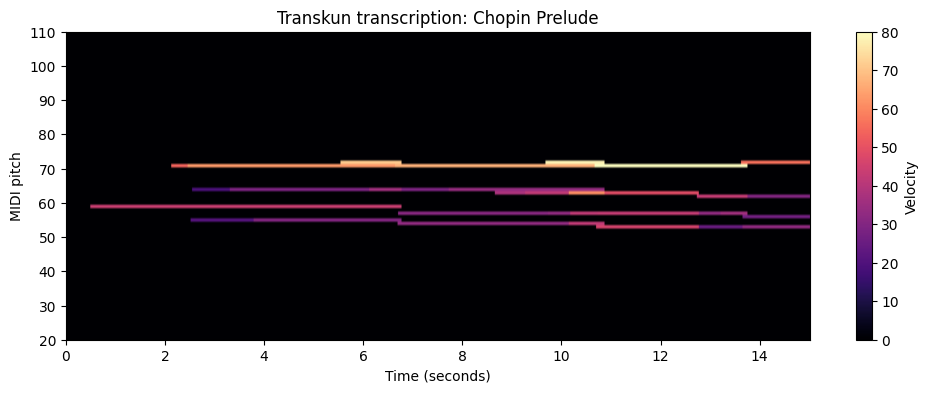

In [ ]:
pm_chopin = pretty_midi.PrettyMIDI(str(CHOPIN_MIDI))
chopin_roll = pm_chopin.get_piano_roll(fs=100)

plt.figure(figsize=(12, 4))
plt.imshow(
    chopin_roll,
    origin="lower",
    aspect="auto",
    cmap="magma",
    extent=[0, pm_chopin.get_end_time(), 0, 127],
)
plt.title("Transkun transcription: Chopin Prelude")
plt.xlabel("Time (seconds)")
plt.ylabel("MIDI pitch")
plt.ylim(20, 110)
plt.colorbar(label="Velocity")
plt.show()

### 생성된 MIDI 들어보기

채보 결과를 FluidSynth로 다시 합성합니다. 원본 연주와 비교하면서 빠진 음, 추가된 음, 음의 길이가 다른 부분을 찾아보세요.

In [ ]:
SOUNDFONT = Path("/usr/share/sounds/sf2/FluidR3_GM.sf2")
if not SOUNDFONT.exists():
    soundfonts = list(Path("/usr/share/sounds").rglob("*.sf2"))
    if not soundfonts:
        raise FileNotFoundError("사용 가능한 SoundFont를 찾지 못했습니다.")
    SOUNDFONT = soundfonts[0]

chopin_synth = pm_chopin.fluidsynth(fs=44100, sf2_path=str(SOUNDFONT))
ipd.Audio(chopin_synth, rate=44100)

/tmp/ipykernel_1125/961545179.py:8: DeprecationWarning: The parameter 'sf2_path' is deprecated, please use 'synthesizer' instead.
  chopin_synth = pm_chopin.fluidsynth(fs=44100, sf2_path=str(SOUNDFONT))


# 3. Basic Pitch: 다중 악기 자동 채보

Basic Pitch는 Spotify가 공개한 경량 자동 채보 모델입니다. 이번에는 베토벤 현악 사중주를 입력해 봅니다.

피아노와 비교하여 현악기 채보가 어려운 이유를 생각해 보세요.

- 현악기는 음의 시작이 피아노처럼 명확하지 않을 수 있습니다.
- 비브라토와 포르타멘토 때문에 음높이가 계속 변할 수 있습니다.
- 여러 악기가 비슷한 음역에서 동시에 연주합니다.

In [ ]:
# 베토벤 악보와 입력 오디오 확인
display(ipd.Image(filename=str(BEETHOVEN_SCORE), width=1000))
display(ipd.Audio(filename=str(BEETHOVEN_AUDIO)))

Output hidden; open in https://colab.research.google.com to view.

### Basic Pitch 실행

현재 Colab 환경에서는 호환성이 좋은 ONNX 모델을 사용합니다. 결과로 모델 출력, MIDI 객체, 개별 노트 이벤트 목록을 얻습니다.

In [ ]:
from basic_pitch.inference import predict
from basic_pitch import ICASSP_2022_MODEL_PATH

print(f"사용 모델: {ICASSP_2022_MODEL_PATH}")
model_output, midi_data, note_events = predict(
    str(BEETHOVEN_AUDIO),
    model_or_model_path=ICASSP_2022_MODEL_PATH,
)

BEETHOVEN_MIDI = OUTPUT_DIR / "beethoven_basic_pitch.mid"
midi_data.write(str(BEETHOVEN_MIDI))
print(f"✅ {len(note_events)}개의 노트를 검출했습니다.")
print(f"✅ MIDI 저장: {BEETHOVEN_MIDI}")

사용 모델: /usr/local/lib/python3.12/dist-packages/basic_pitch/saved_models/icassp_2022/nmp
Predicting MIDI for /content/ksmpc_amt_materials/Beethoven_strqrt.wav...
✅ 83개의 노트를 검출했습니다.
✅ MIDI 저장: /content/ksmpc_amt_results/beethoven_basic_pitch.mid


### 모델이 추정한 음높이 분포

아래 그림은 시간에 따른 음높이 후보의 확률을 보여줍니다. 현악기의 비브라토가 있는 구간에서는 에너지가 위아래로 흔들리는 모습을 관찰할 수 있습니다.

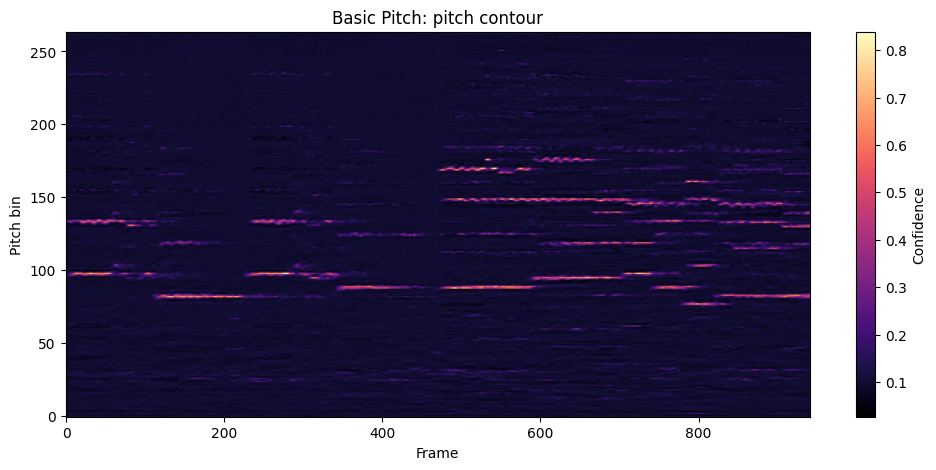

In [ ]:
plt.figure(figsize=(12, 5))
plt.imshow(
    model_output["contour"].T,
    aspect="auto",
    origin="lower",
    cmap="magma",
)
plt.title("Basic Pitch: pitch contour")
plt.xlabel("Frame")
plt.ylabel("Pitch bin")
plt.colorbar(label="Confidence")
plt.show()

### MIDI 피아노롤

연속적인 음높이 확률에서 실제 MIDI 노트의 시작과 끝을 결정한 결과입니다.

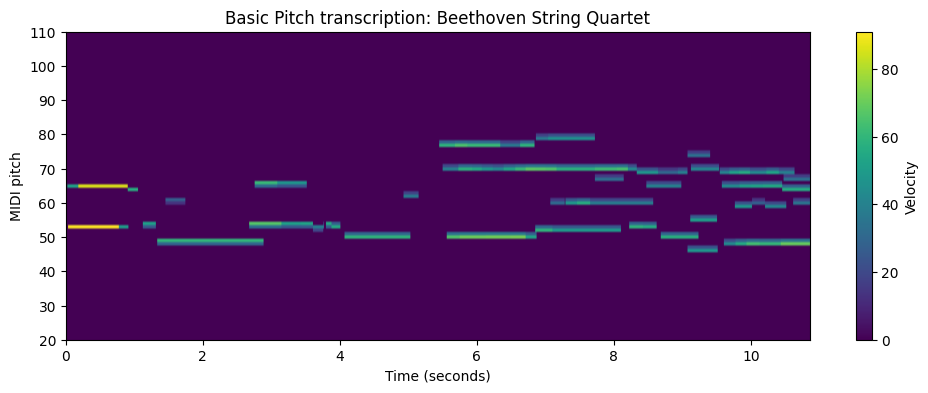

In [ ]:
beethoven_roll = midi_data.get_piano_roll(fs=100)

plt.figure(figsize=(12, 4))
plt.imshow(
    beethoven_roll,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    extent=[0, midi_data.get_end_time(), 0, 127],
)
plt.title("Basic Pitch transcription: Beethoven String Quartet")
plt.xlabel("Time (seconds)")
plt.ylabel("MIDI pitch")
plt.ylim(20, 110)
plt.colorbar(label="Velocity")
plt.show()

### 노트와 피치 벤드 함께 보기

파란색은 MIDI 노트, 빨간색은 노트 내부에서 추정된 미세한 음높이 변화를 나타냅니다.

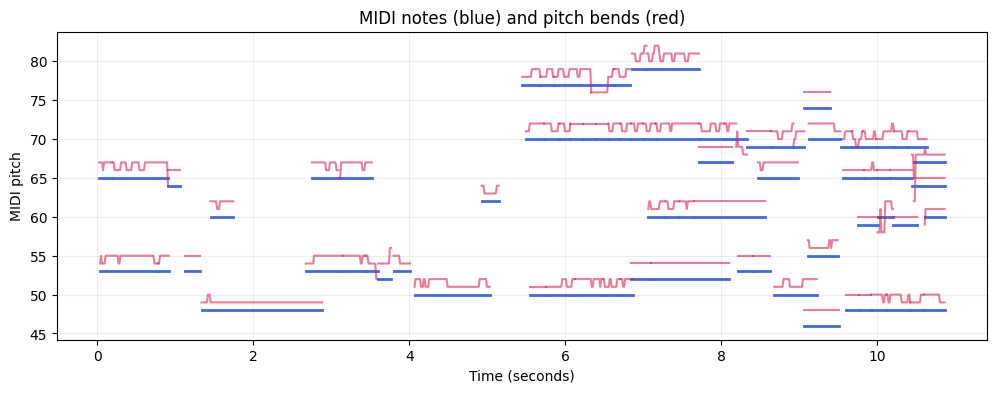

In [ ]:
plt.figure(figsize=(12, 4))

for start, end, pitch, velocity, pitch_bend in note_events:
    plt.plot([start, end], [pitch, pitch], color="royalblue", linewidth=2)
    if pitch_bend:
        times = np.linspace(start, end, len(pitch_bend))
        plt.plot(
            times,
            pitch + np.asarray(pitch_bend),
            color="crimson",
            alpha=0.55,
        )

plt.title("MIDI notes (blue) and pitch bends (red)")
plt.xlabel("Time (seconds)")
plt.ylabel("MIDI pitch")
plt.grid(alpha=0.2)
plt.show()

# 4. 두 모델 비교하기

실습 결과를 바탕으로 다음을 함께 이야기해 봅시다.

1. 원본 오디오와 합성된 MIDI는 어떤 점이 다르게 들리나요?
2. Transkun의 피아노 채보와 Basic Pitch의 현악기 채보에서 어떤 오류가 보이나요?
3. 음의 시작, 끝, 음높이, 강약 중 모델이 가장 잘 추정한 것은 무엇인가요?
4. 악보와 연주 오디오가 정확히 일치하지 않을 때 평가는 어떻게 해야 할까요?

생성된 MIDI 파일은 `/content/ksmpc_amt_results/`에 있습니다.

In [ ]:
# 생성 결과 확인 및 다운로드
from google.colab import files

print("생성된 파일:")
for path in sorted(OUTPUT_DIR.glob("*.mid")):
    print(" -", path.name)

# 필요한 경우 아래 두 줄의 주석을 해제하여 내려받으세요.
# files.download(str(CHOPIN_MIDI))
# files.download(str(BEETHOVEN_MIDI))